# 02 - Feature Engineering

Neste notebook vamos criar, testar e analisar novas features
para melhorar a previsão de churn dos clientes do SUSE Beleza.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("../feature-engineering/output/dataset_churn.csv")

In [4]:
df.head()

,cliente_id,total_atendimentos,total_gasto,ticket_medio,dias_desde_ultimo_atendimento,intervalo_medio_atendimentos,atendimentos_30d,atendimentos_90d,gasto_90d,quantidade_servicos_diferentes,quantidade_profissionais_diferentes,target_churn
0,mock-cli-00001,1,162.48,162.48,99,0.00,0,0,0.00,1,1,1
1,mock-cli-00002,7,1495.73,213.68,3,61.50,1,2,147.79,8,5,0
2,mock-cli-00003,0,0.00,0.00,-1,0.00,0,0,0.00,0,0,1
3,mock-cli-00004,0,0.00,0.00,-1,0.00,0,0,0.00,0,0,1
4,mock-cli-00005,7,1208.66,172.67,1,53.67,1,2,811.75,7,5,0


In [5]:
df.columns.tolist()

['cliente_id',
 'total_atendimentos',
 'total_gasto',
 'ticket_medio',
 'dias_desde_ultimo_atendimento',
 'intervalo_medio_atendimentos',
 'atendimentos_30d',
 'atendimentos_90d',
 'gasto_90d',
 'quantidade_servicos_diferentes',
 'quantidade_profissionais_diferentes',
 'target_churn']

In [6]:
df.dtypes

cliente_id                                 str
total_atendimentos                       int64
total_gasto                            float64
ticket_medio                           float64
dias_desde_ultimo_atendimento            int64
intervalo_medio_atendimentos           float64
atendimentos_30d                         int64
atendimentos_90d                         int64
gasto_90d                              float64
quantidade_servicos_diferentes           int64
quantidade_profissionais_diferentes      int64
target_churn                             int64
dtype: object

## 1. Atraso em relação ao intervalo habitual

In [6]:
df["atraso_vs_intervalo_medio"] = (
    df["dias_desde_ultimo_atendimento"]
    - df["intervalo_medio_atendimentos"]
)

In [8]:
df[
    [
        "dias_desde_ultimo_atendimento",
        "intervalo_medio_atendimentos",
        "atraso_vs_intervalo_medio",
        "target_churn"
    ]
].head(20)

,dias_desde_ultimo_atendimento,intervalo_medio_atendimentos,atraso_vs_intervalo_medio,target_churn
0,99,0.00,99.00,1
1,3,61.50,-58.50,0
2,-1,0.00,-1.00,1
3,-1,0.00,-1.00,1
4,1,53.67,-52.67,0
5,89,41.00,48.00,0
6,136,80.67,55.33,0
7,66,52.50,13.50,1
8,26,66.50,-40.50,0
9,29,0.00,29.00,0


In [9]:
df.groupby("target_churn")[
    "atraso_vs_intervalo_medio"
].agg(
    ["mean", "median", "min", "max"]
).round(2)

,mean,median,min,max
target_churn,,,,
0,0.70,-1.0,-216.0,350.0
1,5.08,-1.0,-179.5,337.0


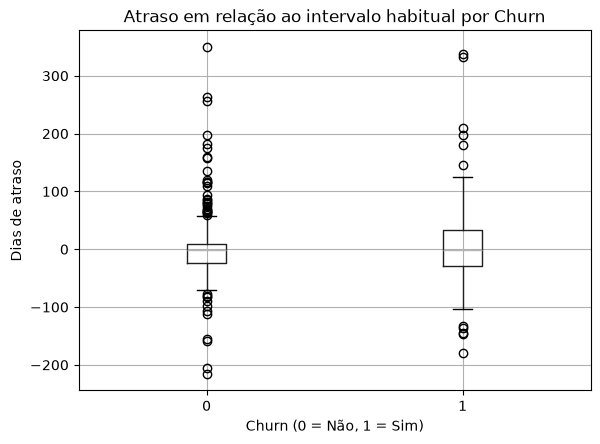

In [10]:
df.boxplot(
    column="atraso_vs_intervalo_medio",
    by="target_churn"
)

plt.title("Atraso em relação ao intervalo habitual por Churn")
plt.suptitle("")
plt.xlabel("Churn (0 = Não, 1 = Sim)")
plt.ylabel("Dias de atraso")

plt.show()

In [7]:
df["atraso_percentual"] = np.where(
    df["intervalo_medio_atendimentos"] > 0,
    df["atraso_vs_intervalo_medio"]
    / df["intervalo_medio_atendimentos"],
    0
)

In [8]:
df.to_csv(
    "../feature-engineering/output/dataset_churn_features.csv",
    index=False
)

In [9]:
print(df.columns.tolist())

['cliente_id', 'total_atendimentos', 'total_gasto', 'ticket_medio', 'dias_desde_ultimo_atendimento', 'intervalo_medio_atendimentos', 'atendimentos_30d', 'atendimentos_90d', 'gasto_90d', 'quantidade_servicos_diferentes', 'quantidade_profissionais_diferentes', 'target_churn', 'atraso_vs_intervalo_medio', 'atraso_percentual']


In [12]:
df.groupby("target_churn")[
    "atraso_percentual"
].agg(
    ["mean", "median", "min", "max"]
).round(2)

,mean,median,min,max
target_churn,,,,
0,-0.15,0.0,-1.0,2.06
1,-0.01,0.0,-1.0,3.20


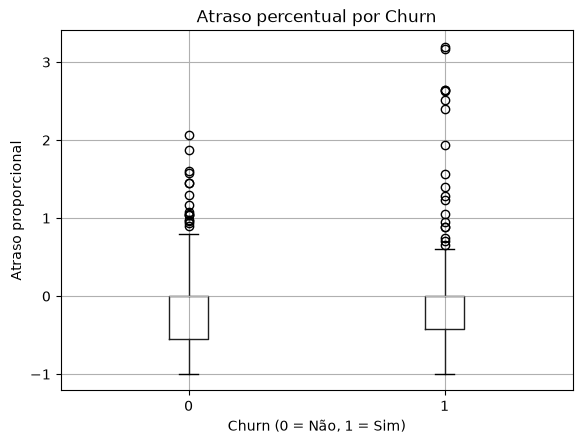

In [13]:
df.boxplot(
    column="atraso_percentual",
    by="target_churn"
)

plt.title("Atraso percentual por Churn")
plt.suptitle("")
plt.xlabel("Churn (0 = Não, 1 = Sim)")
plt.ylabel("Atraso proporcional")

plt.show()

In [14]:
df["proporcao_atendimentos_30d"] = np.where(
    df["atendimentos_90d"] > 0,
    df["atendimentos_30d"] / df["atendimentos_90d"],
    0
)

In [15]:
novas_features = [
    "atraso_vs_intervalo_medio",
    "atraso_percentual",
    "proporcao_atendimentos_30d"
]

df[novas_features].describe().round(2)

,atraso_vs_intervalo_medio,atraso_percentual,proporcao_atendimentos_30d
count,500.00,500.00,500.00
mean,2.22,-0.10,0.23
std,60.41,0.62,0.34
min,-216.00,-1.00,0.00
25%,-24.08,-0.52,0.00
50%,-1.00,0.00,0.00
75%,19.00,0.00,0.50
max,350.00,3.20,1.00


In [16]:
df.groupby("target_churn")[novas_features].mean().round(2)

,atraso_vs_intervalo_medio,atraso_percentual,proporcao_atendimentos_30d
target_churn,,,
0,0.70,-0.15,0.22
1,5.08,-0.01,0.23


In [17]:
df[
    novas_features + ["target_churn"]
].corr().round(2)

df[
    novas_features + ["target_churn"]
].corr()["target_churn"].sort_values().round(2)

proporcao_atendimentos_30d    0.01
atraso_vs_intervalo_medio     0.03
atraso_percentual             0.11
target_churn                  1.00
Name: target_churn, dtype: float64

In [18]:
df.groupby("target_churn")[
    [
        "atraso_vs_intervalo_medio",
        "atraso_percentual",
        "proporcao_atendimentos_30d"
    ]
].mean().round(2)

,atraso_vs_intervalo_medio,atraso_percentual,proporcao_atendimentos_30d
target_churn,,,
0,0.70,-0.15,0.22
1,5.08,-0.01,0.23


In [19]:
df[
    [
        "atraso_vs_intervalo_medio",
        "atraso_percentual",
        "proporcao_atendimentos_30d",
        "target_churn"
    ]
].corr()["target_churn"].sort_values().round(2)

proporcao_atendimentos_30d    0.01
atraso_vs_intervalo_medio     0.03
atraso_percentual             0.11
target_churn                  1.00
Name: target_churn, dtype: float64

In [20]:
features_todas = [
    "total_atendimentos",
    "total_gasto",
    "ticket_medio",
    "dias_desde_ultimo_atendimento",
    "intervalo_medio_atendimentos",
    "atendimentos_30d",
    "atendimentos_90d",
    "gasto_90d",
    "atraso_vs_intervalo_medio",
    "atraso_percentual",
    "proporcao_atendimentos_30d"
]

correlacoes = (
    df[features_todas + ["target_churn"]]
    .corr()["target_churn"]
    .drop("target_churn")
    .sort_values()
)

correlacoes.round(2)

atendimentos_90d                -0.24
gasto_90d                       -0.23
total_gasto                     -0.20
total_atendimentos              -0.18
atendimentos_30d                -0.12
ticket_medio                    -0.10
proporcao_atendimentos_30d       0.01
atraso_vs_intervalo_medio        0.03
intervalo_medio_atendimentos     0.07
dias_desde_ultimo_atendimento    0.09
atraso_percentual                0.11
Name: target_churn, dtype: float64

In [21]:
features_modelo_a = [
    "total_atendimentos",
    "total_gasto",
    "ticket_medio",
    "dias_desde_ultimo_atendimento",
    "intervalo_medio_atendimentos",
    "atendimentos_30d",
    "atendimentos_90d",
    "gasto_90d"
]

In [22]:
features_modelo_b = features_modelo_a + [
    "atraso_vs_intervalo_medio",
    "atraso_percentual"
]

In [23]:
print("Features Modelo A:")
print(features_modelo_a)

print("\nFeatures Modelo B:")
print(features_modelo_b)

print("\nQuantidade de registros:", len(df))

Features Modelo A:
['total_atendimentos', 'total_gasto', 'ticket_medio', 'dias_desde_ultimo_atendimento', 'intervalo_medio_atendimentos', 'atendimentos_30d', 'atendimentos_90d', 'gasto_90d']

Features Modelo B:
['total_atendimentos', 'total_gasto', 'ticket_medio', 'dias_desde_ultimo_atendimento', 'intervalo_medio_atendimentos', 'atendimentos_30d', 'atendimentos_90d', 'gasto_90d', 'atraso_vs_intervalo_medio', 'atraso_percentual']

Quantidade de registros: 500


In [24]:
df[features_modelo_b + ["target_churn"]].isnull().sum()

total_atendimentos               0
total_gasto                      0
ticket_medio                     0
dias_desde_ultimo_atendimento    0
intervalo_medio_atendimentos     0
atendimentos_30d                 0
atendimentos_90d                 0
gasto_90d                        0
atraso_vs_intervalo_medio        0
atraso_percentual                0
target_churn                     0
dtype: int64

In [25]:
np.isinf(
    df[features_modelo_b]
).sum()

total_atendimentos               0
total_gasto                      0
ticket_medio                     0
dias_desde_ultimo_atendimento    0
intervalo_medio_atendimentos     0
atendimentos_30d                 0
atendimentos_90d                 0
gasto_90d                        0
atraso_vs_intervalo_medio        0
atraso_percentual                0
dtype: int64

In [26]:
df_modelo = df[
    features_modelo_b + ["target_churn"]
].copy()

In [27]:
df_modelo.shape

(500, 11)

In [28]:
X = df_modelo.drop(
    columns=["target_churn"]
)

y = df_modelo["target_churn"]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [32]:
print("Treinamento:", X_train.shape)
print("Teste:", X_test.shape)

print("\nDistribuição treino:")
print(y_train.value_counts())

print("\nDistribuição teste:")
print(y_test.value_counts())

Treinamento: (400, 10)
Teste: (100, 10)

Distribuição treino:
target_churn
0    261
1    139
Name: count, dtype: int64

Distribuição teste:
target_churn
0    65
1    35
Name: count, dtype: int64
